In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# scikit-image 최신 버전 설치
!pip install scikit-image --quiet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import os

import warnings
warnings.filterwarnings("ignore")

# 파일 확인 — ['LSWMD.pkl'] 이 나와야 정상
print(os.listdir("/content/drive/MyDrive/input"))

['LSWMD.pkl']


In [ ]:
# pkl 파일 불러오기
df = pd.read_pickle("/content/drive/MyDrive/input/LSWMD.pkl")
df.info()

df.head()   # 앞 5행
df.tail()   # 뒤 5행

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
811452,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,23.0,[[Test]],[[Edge-Ring]]
811453,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 1, 1,...",600.0,lot47542,24.0,[[Test]],[[Edge-Loc]]
811454,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47542,25.0,[[Test]],[[Edge-Ring]]
811455,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,...",600.0,lot47543,1.0,[],[]
811456,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,...",600.0,lot47543,2.0,[],[]


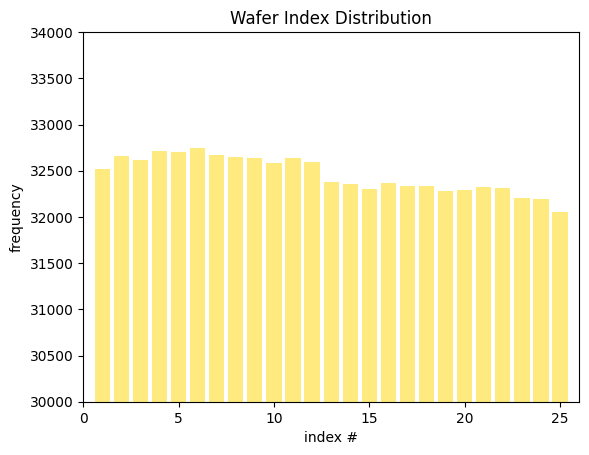

In [ ]:
uni_Index = np.unique(df.waferIndex, return_counts=True)
plt.bar(uni_Index[0], uni_Index[1], color='gold', align='center', alpha=0.5)
plt.title("Wafer Index Distribution")
plt.xlabel("index #")
plt.ylabel("frequency")
plt.xlim(0, 26)
plt.ylim(30000, 34000)
plt.show()

# waferIndex 열 제거 (분류에 불필요)
df = df.drop(['waferIndex'], axis=1)


In [ ]:
def find_dim(x):
    dim0 = np.size(x, axis=0)
    dim1 = np.size(x, axis=1)
    return dim0, dim1

df['waferMapDim'] = df.waferMap.apply(find_dim)
df.sample(5)
print("최대:", max(df.waferMapDim))
print("최소:", min(df.waferMapDim))

uni_waferDim = np.unique(df.waferMapDim, return_counts=True)
print("크기 종류 수:", uni_waferDim[0].shape[0])   # → 632


최대: (300, 202)
최소: (6, 21)
크기 종류 수: 632


In [ ]:
df['failureNum']  = df.failureType
df['trainTestNum'] = df.trianTestLabel

mapping_type = {
    'Center':0, 'Donut':1, 'Edge-Loc':2, 'Edge-Ring':3,
    'Loc':4, 'Random':5, 'Scratch':6, 'Near-full':7, 'none':8
}
mapping_traintest = {'Training': 0, 'Test': 1}

df = df.replace({'failureNum': mapping_type, 'trainTestNum': mapping_traintest})
tol_wafers = df.shape[0]
print("총 wafer 수:", tol_wafers)   # → 811457

# 라벨 있는 것 / 패턴 있는 것 / none 분리
df_withlabel   = df[(df['failureNum'] >= 0) & (df['failureNum'] <= 8)].reset_index()
df_withpattern = df[(df['failureNum'] >= 0) & (df['failureNum'] <= 7)].reset_index()
df_nonpattern  = df[(df['failureNum'] == 8)].reset_index()

print("라벨 있는 wafer:", df_withlabel.shape[0])    # → 172950
print("패턴 있는 wafer:", df_withpattern.shape[0])  # → 25519
print("none wafer:", df_nonpattern.shape[0])         # → 147431

총 wafer 수: 811457
라벨 있는 wafer: 172950
패턴 있는 wafer: 25519
none wafer: 147431


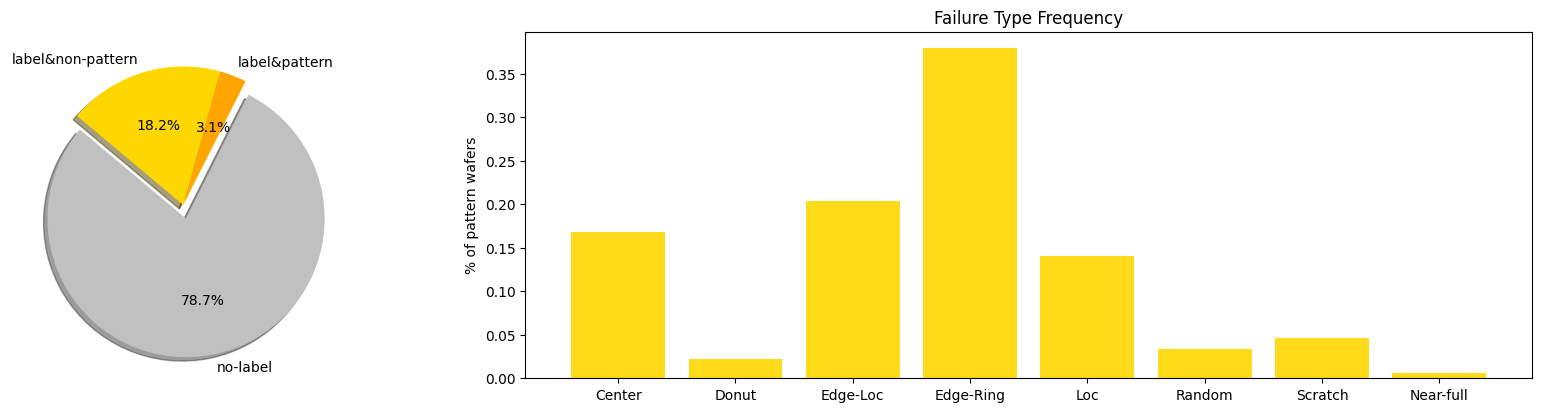

In [ ]:
from matplotlib import gridspec

fig = plt.figure(figsize=(20, 4.5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5])
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

no_wafers = [
    tol_wafers - df_withlabel.shape[0],
    df_withpattern.shape[0],
    df_nonpattern.shape[0]
]
colors  = ['silver', 'orange', 'gold']
explode = (0.1, 0, 0)
labels  = ['no-label', 'label&pattern', 'label&non-pattern']
ax1.pie(no_wafers, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

uni_pattern = np.unique(df_withpattern.failureNum, return_counts=True)
labels2 = ['', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
           'Loc', 'Random', 'Scratch', 'Near-full']
ax2.bar(uni_pattern[0], uni_pattern[1] / df_withpattern.shape[0],
        color='gold', align='center', alpha=0.9)
ax2.set_title("Failure Type Frequency")
ax2.set_ylabel("% of pattern wafers")
ax2.set_xticklabels(labels2)
plt.show()


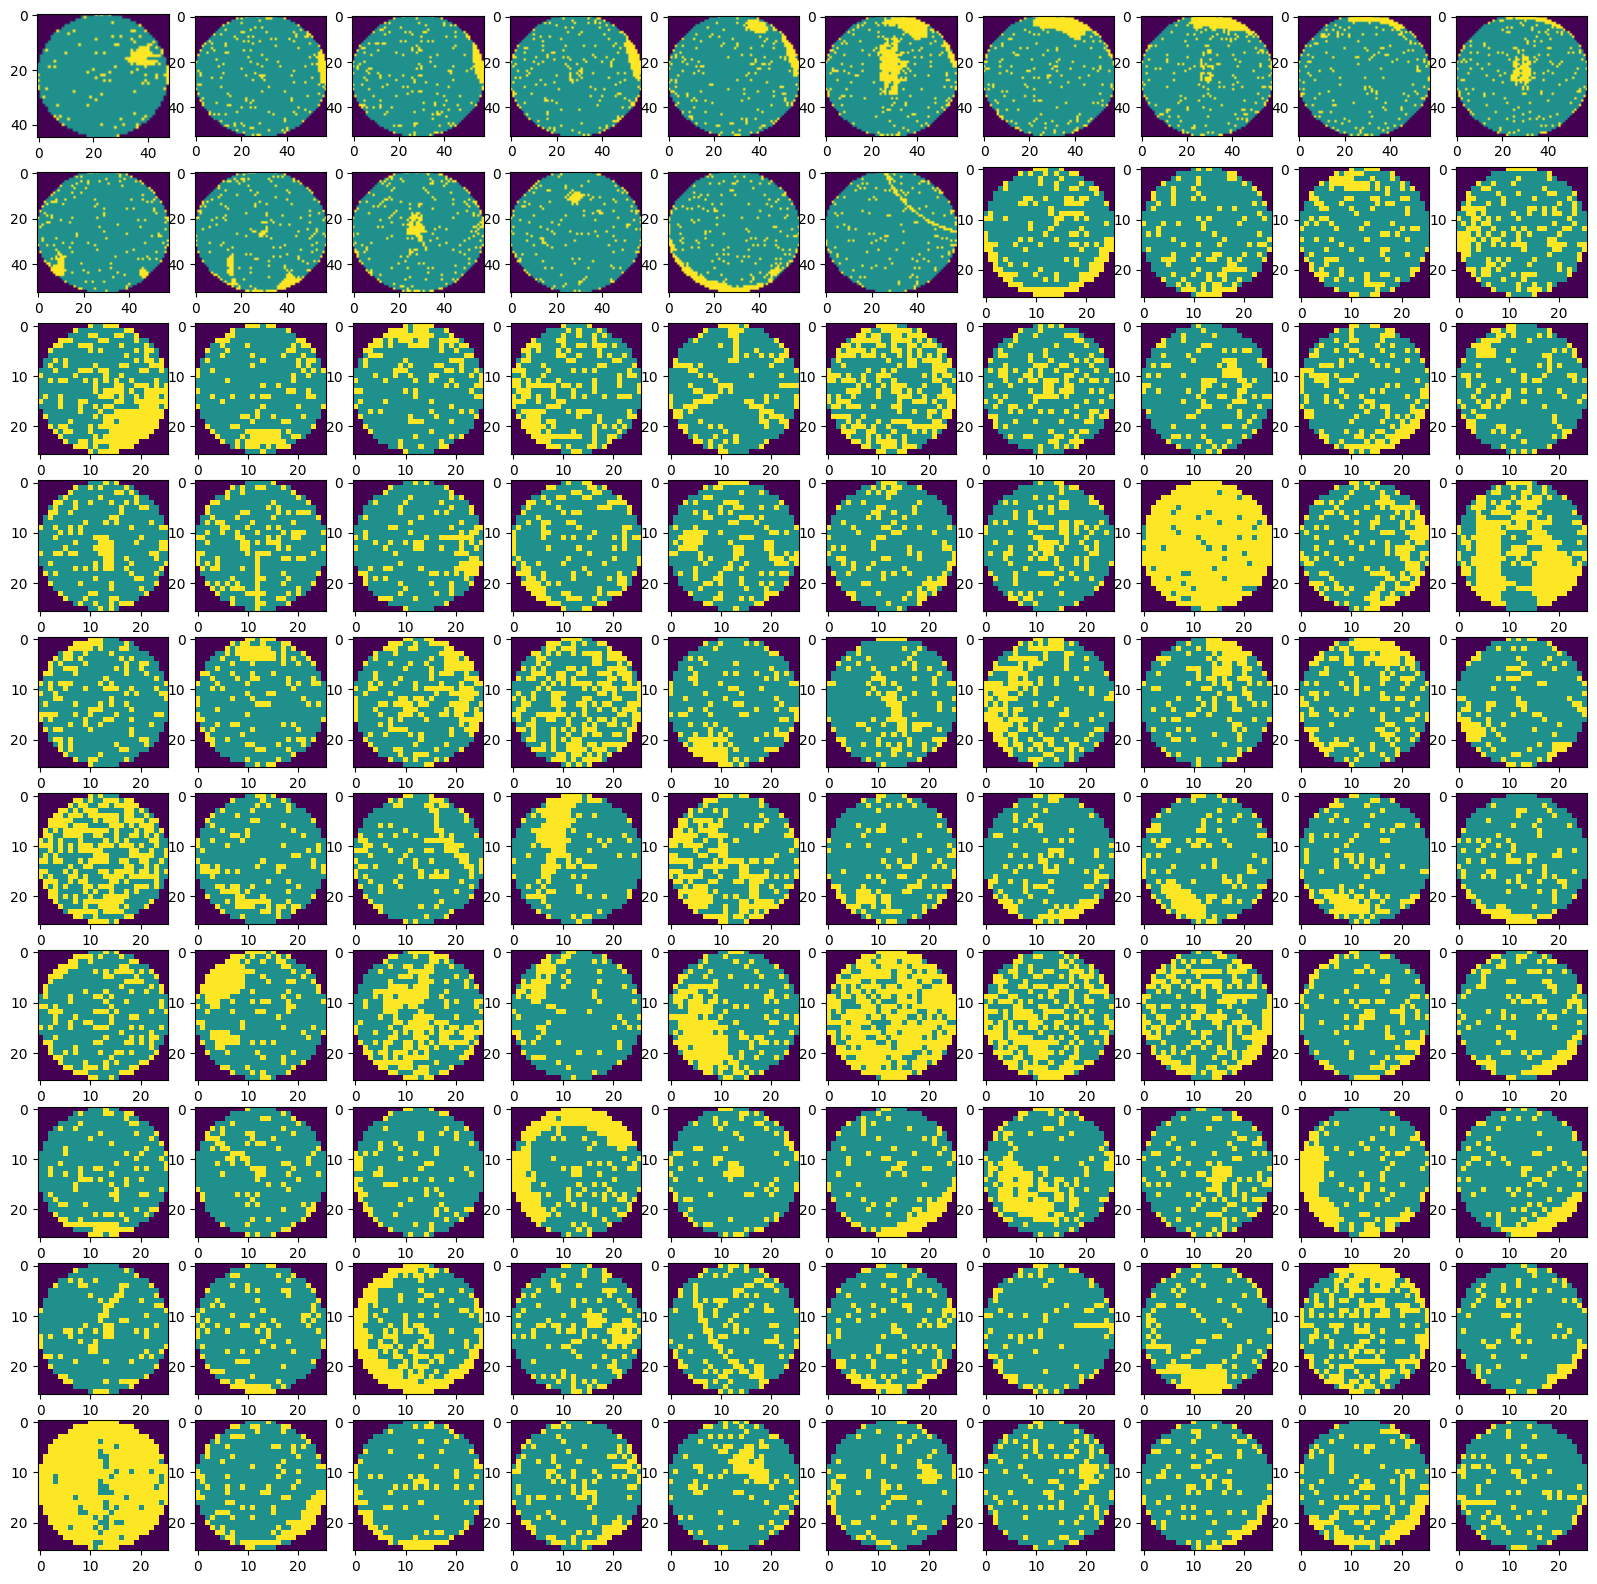

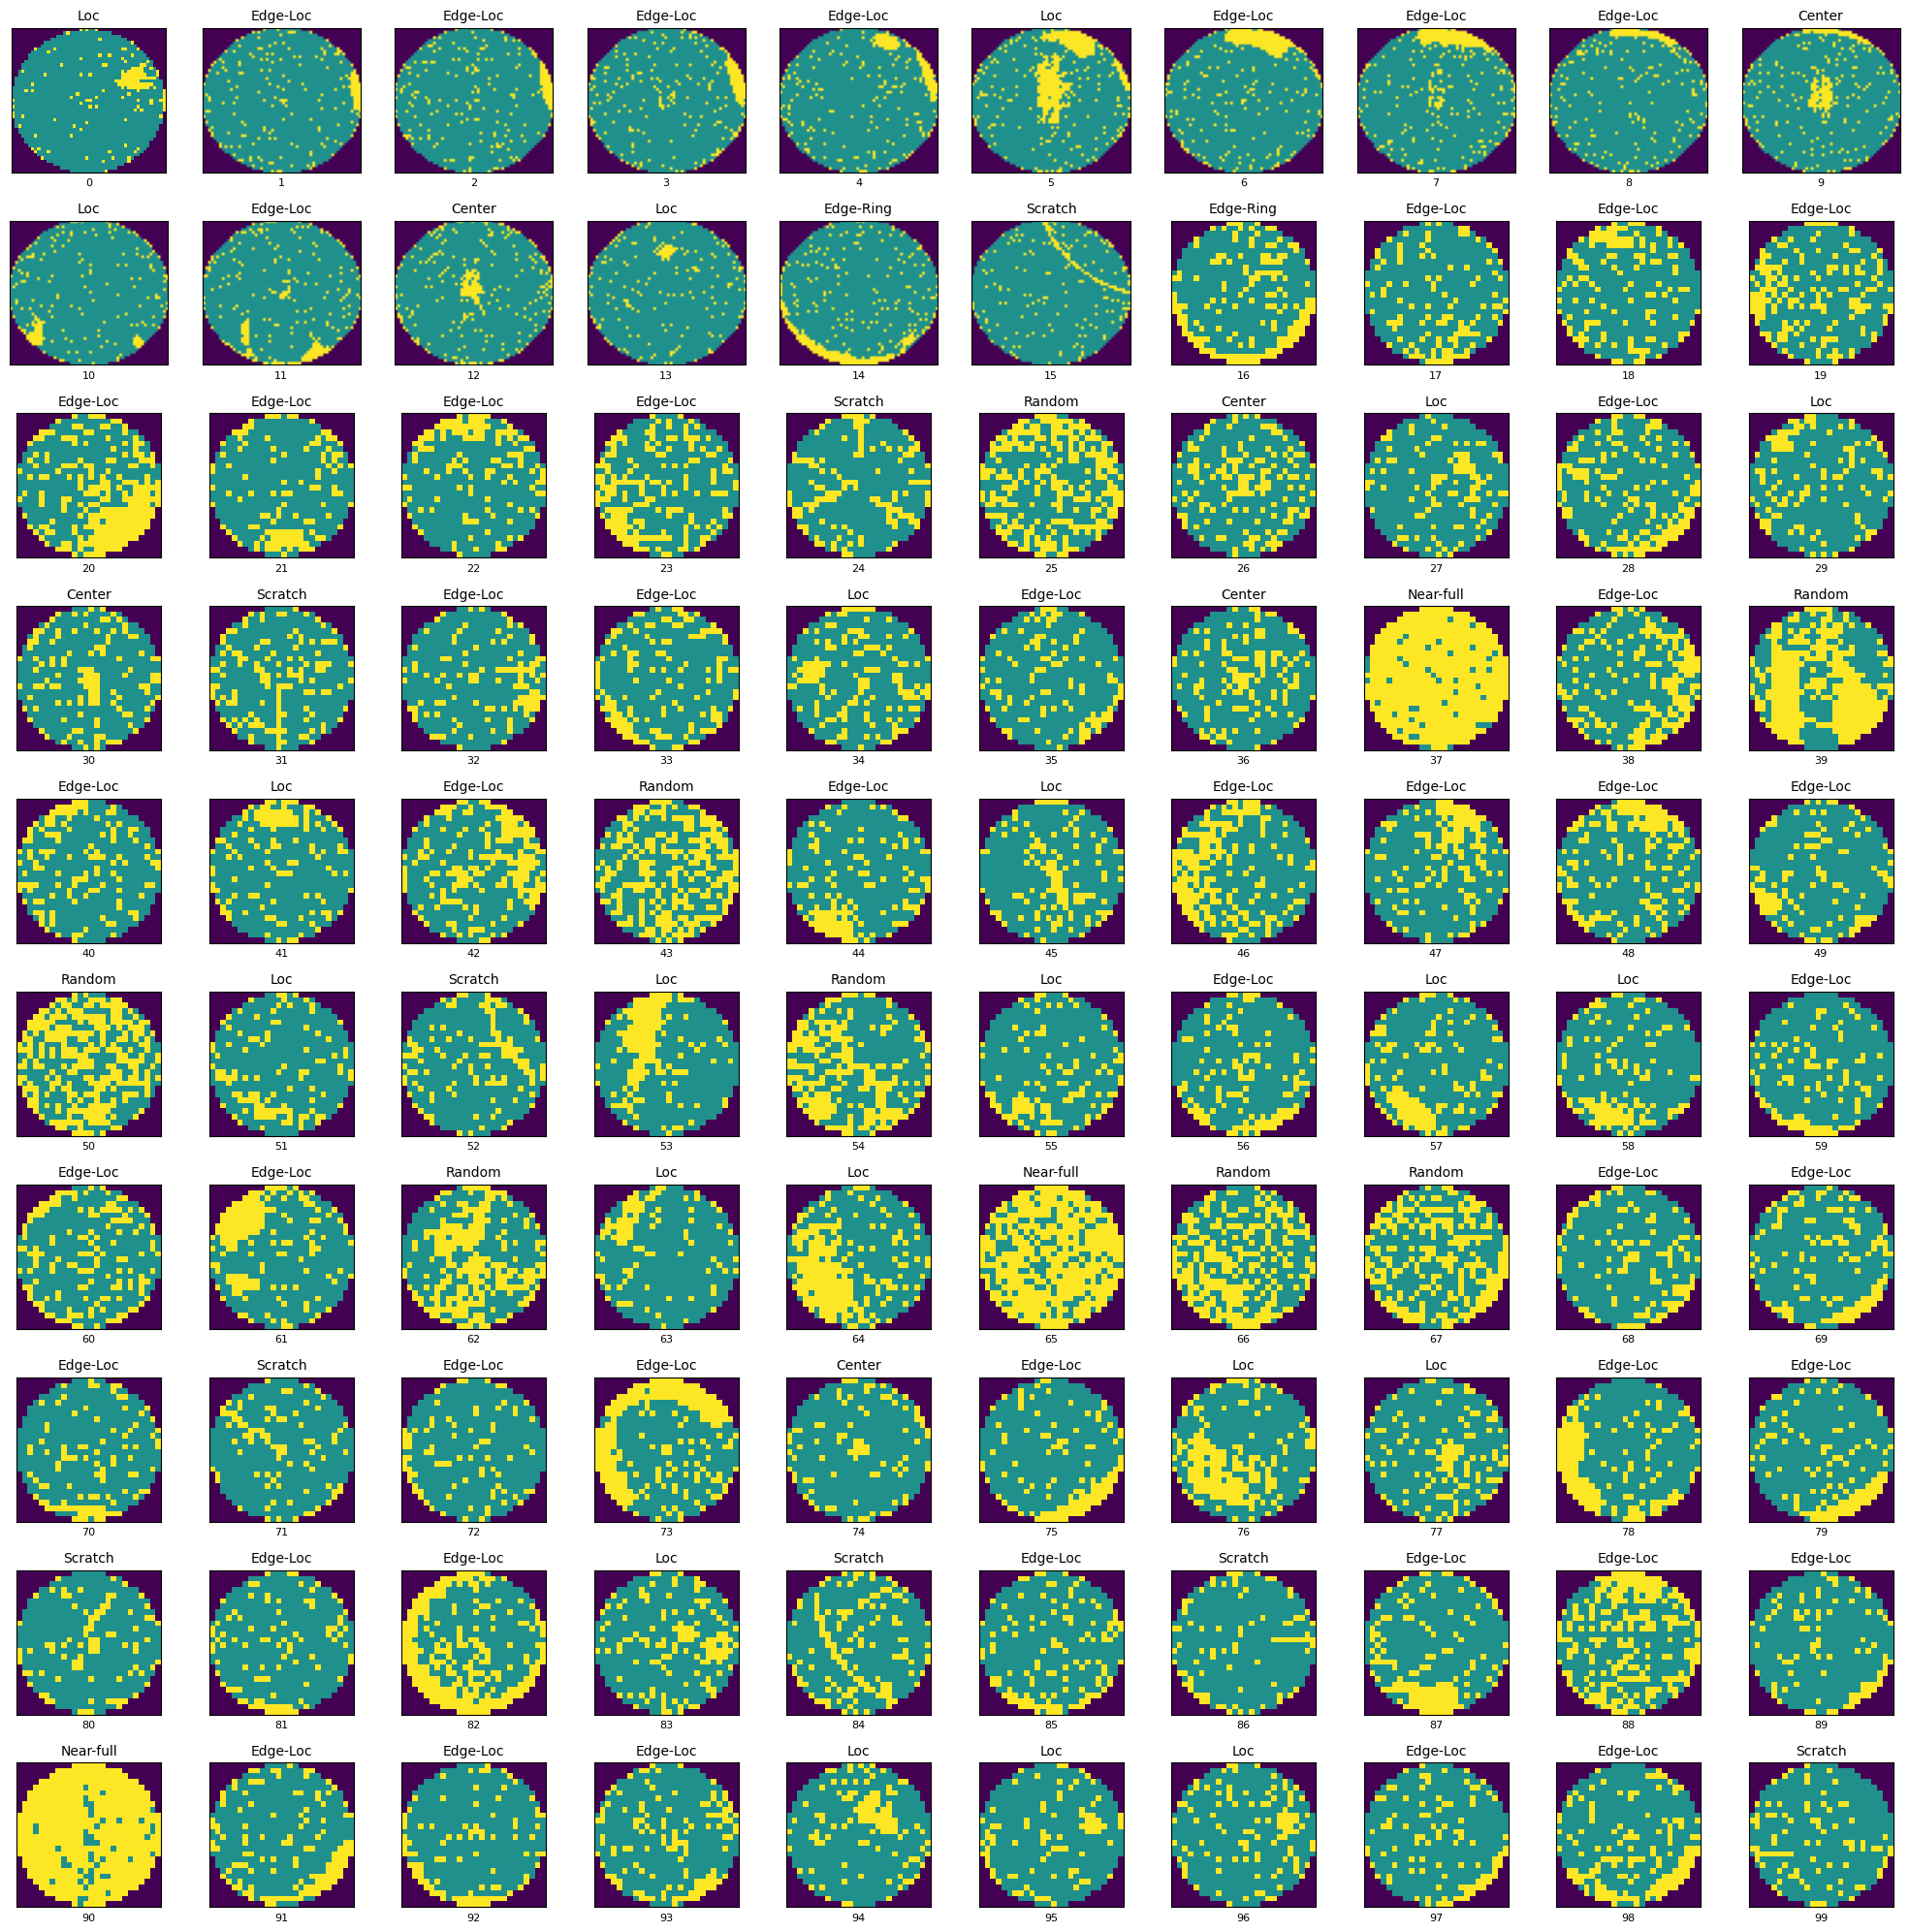

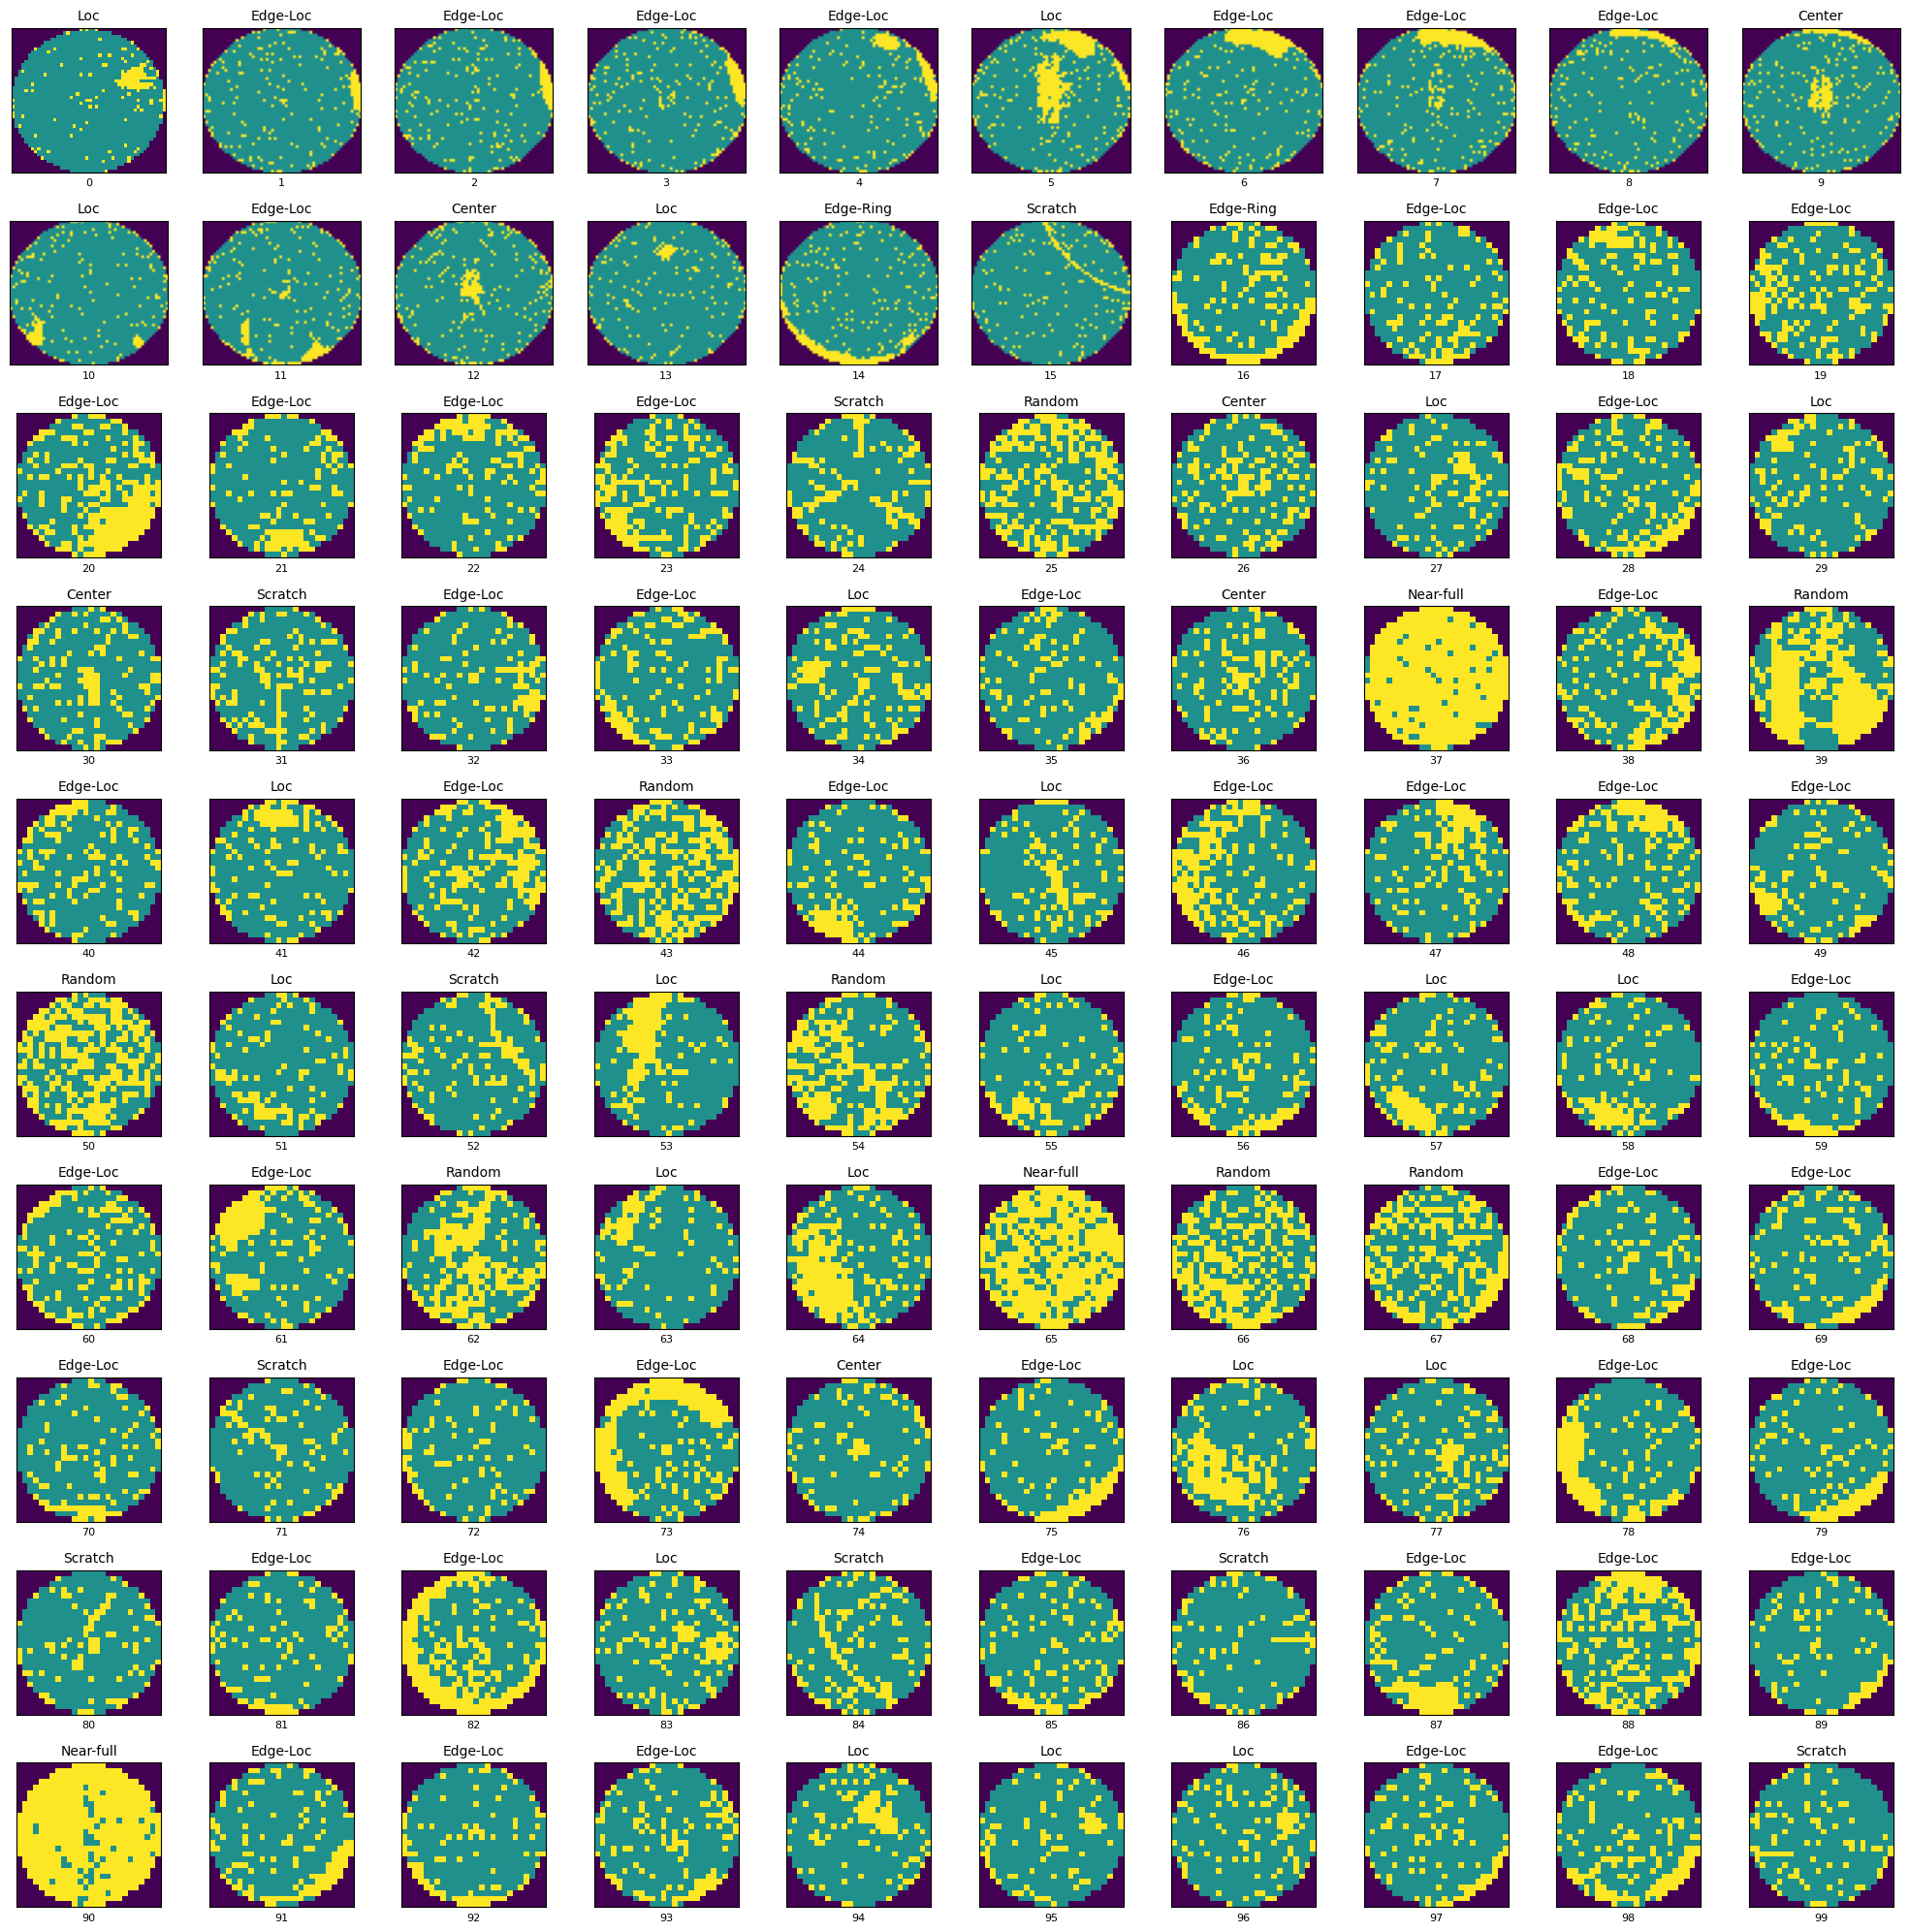

In [ ]:
fig, ax = plt.subplots(nrows=10, ncols=10, figsize=(20, 20))
ax = ax.ravel(order='C')

for i in range(100):
    img = df_withpattern.waferMap[i]
    ax[i].imshow(img)
fig, ax = plt.subplots(nrows=10, ncols=10, figsize=(20, 20))
ax = ax.ravel(order='C')

for i in range(100):
    img = df_withpattern.waferMap[i]
    ax[i].imshow(img)
    ax[i].set_title(df_withpattern.failureType[i][0][0], fontsize=10)
    ax[i].set_xlabel(df_withpattern.index[i], fontsize=8)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(nrows=10, ncols=10, figsize=(20, 20))
ax = ax.ravel(order='C')

for i in range(100):
    img = df_withpattern.waferMap[i]
    ax[i].imshow(img)
    ax[i].set_title(df_withpattern.failureType[i][0][0], fontsize=10)
    ax[i].set_xlabel(df_withpattern.index[i], fontsize=8)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.show()


In [ ]:
import skimage
from skimage import measure
from skimage.transform import radon
from scipy import interpolate
from scipy import stats



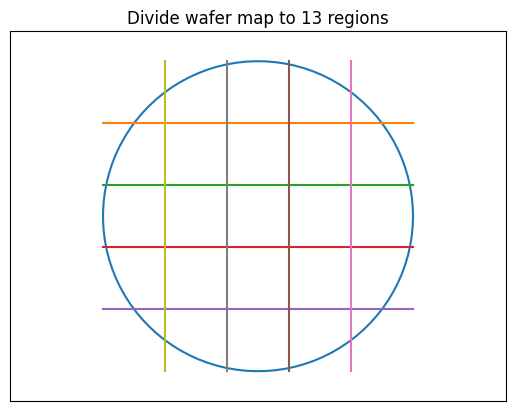

In [ ]:
# 13 구역 시각화
an = np.linspace(0, 2 * np.pi, 100)
plt.plot(2.5 * np.cos(an), 2.5 * np.sin(an))
plt.axis('equal')
plt.axis([-4, 4, -4, 4])
plt.plot([-2.5, 2.5], [1.5, 1.5])
plt.plot([-2.5, 2.5], [0.5, 0.5])
plt.plot([-2.5, 2.5], [-0.5, -0.5])
plt.plot([-2.5, 2.5], [-1.5, -1.5])
plt.plot([0.5, 0.5], [-2.5, 2.5])
plt.plot([1.5, 1.5], [-2.5, 2.5])
plt.plot([-0.5, -0.5], [-2.5, 2.5])
plt.plot([-1.5, -1.5], [-2.5, 2.5])
plt.title("Divide wafer map to 13 regions")
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
# 결함 밀도 = (픽셀 값이 2인 것의 수) / (전체 픽셀 수) * 100
def cal_den(x):
    return 100 * (np.sum(x == 2) / np.size(x))

def find_regions(x):
    rows = np.size(x, axis=0)
    cols = np.size(x, axis=1)
    ind1 = np.arange(0, rows, rows // 5)
    ind2 = np.arange(0, cols, cols // 5)

    reg1  = x[ind1[0]:ind1[1], :]
    reg3  = x[ind1[4]:, :]
    reg4  = x[:, ind2[0]:ind2[1]]
    reg2  = x[:, ind2[4]:]
    reg5  = x[ind1[1]:ind1[2], ind2[1]:ind2[2]]
    reg6  = x[ind1[1]:ind1[2], ind2[2]:ind2[3]]
    reg7  = x[ind1[1]:ind1[2], ind2[3]:ind2[4]]
    reg8  = x[ind1[2]:ind1[3], ind2[1]:ind2[2]]
    reg9  = x[ind1[2]:ind1[3], ind2[2]:ind2[3]]
    reg10 = x[ind1[2]:ind1[3], ind2[3]:ind2[4]]
    reg11 = x[ind1[3]:ind1[4], ind2[1]:ind2[2]]
    reg12 = x[ind1[3]:ind1[4], ind2[2]:ind2[3]]
    reg13 = x[ind1[3]:ind1[4], ind2[3]:ind2[4]]

    return [
        cal_den(reg1),  cal_den(reg2),  cal_den(reg3),  cal_den(reg4),
        cal_den(reg5),  cal_den(reg6),  cal_den(reg7),  cal_den(reg8),
        cal_den(reg9),  cal_den(reg10), cal_den(reg11), cal_den(reg12), cal_den(reg13)
    ]


df_withpattern['fea_reg'] = df_withpattern.waferMap.apply(find_regions)
print("밀도 feature 추출 완료")


밀도 feature 추출 완료


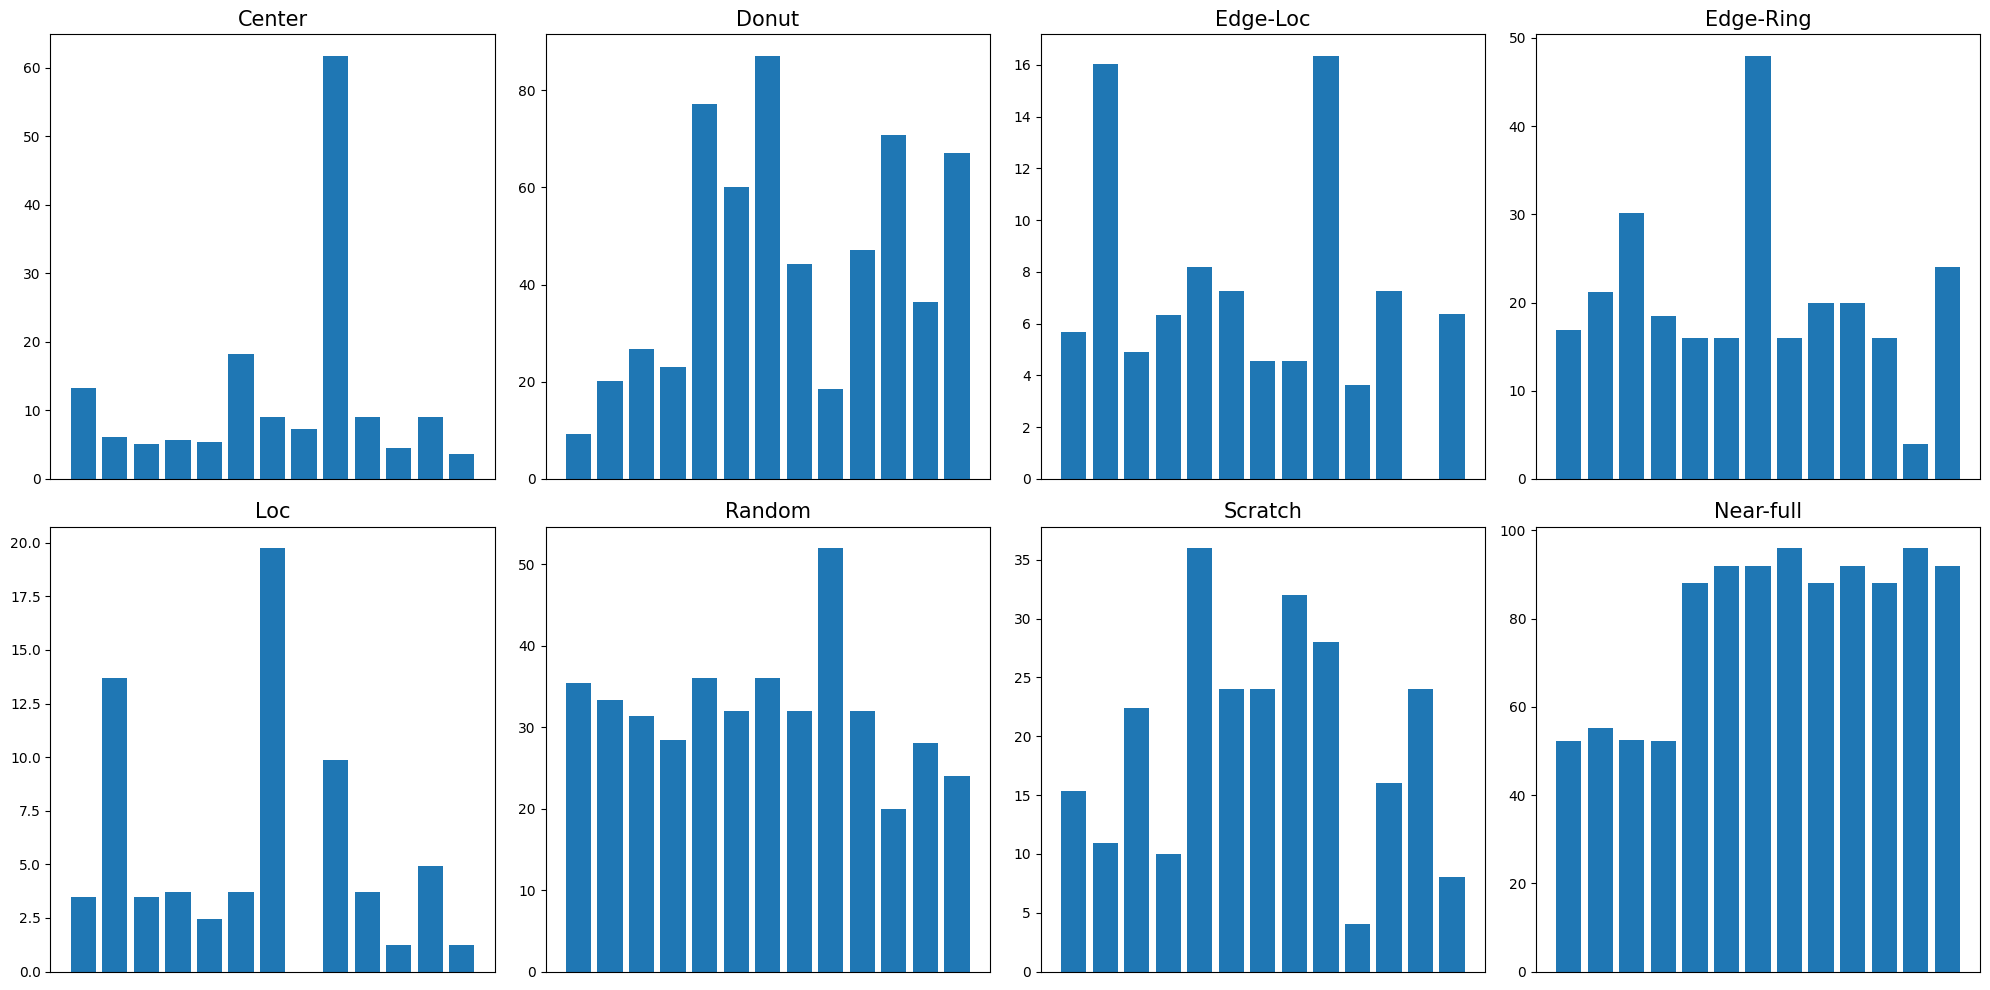

In [ ]:
# 밀도 feature 시각화
x = [9, 340, 3, 16, 0, 25, 84, 37]
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
ax = ax.ravel(order='C')

for i in range(8):
    ax[i].bar(np.linspace(1, 13, 13), df_withpattern.fea_reg[x[i]])
    ax[i].set_title(df_withpattern.failureType[x[i]][0][0], fontsize=15)
    ax[i].set_xticks([])

plt.tight_layout()
plt.show()


In [ ]:
# 작업용 복사본 생성
df_withpattern_copy = df_withpattern.copy()


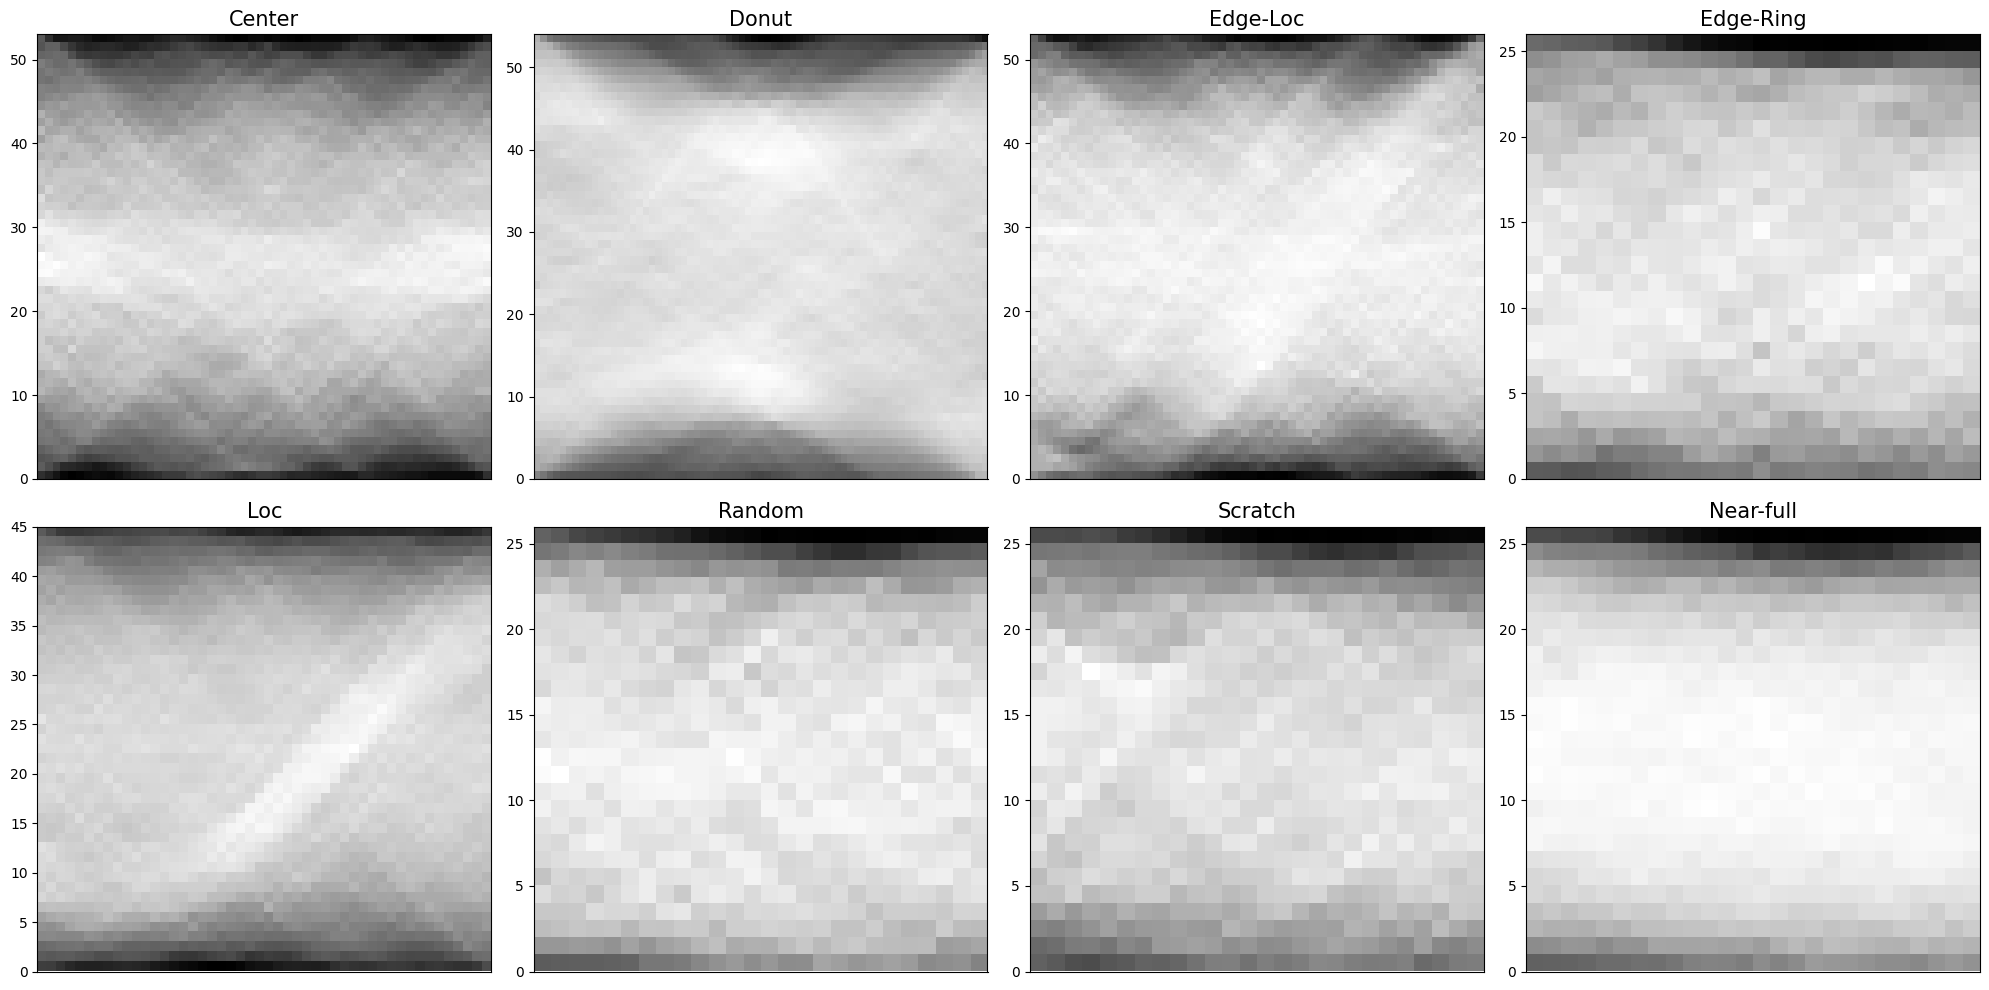

In [ ]:
# 라돈 변환 시각화 (8가지 패턴)
x = [9, 340, 3, 16, 0, 25, 84, 37]
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
ax = ax.ravel(order='C')

for i in range(8):
    img = df_withpattern_copy.waferMap[x[i]]
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)  # ← 오타 수정
    sinogram = radon(img, theta=theta)
    ax[i].imshow(sinogram, cmap=plt.cm.Greys_r,
                 extent=(0, 180, 0, sinogram.shape[0]), aspect='auto')
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0], fontsize=15)
    ax[i].set_xticks([])

plt.tight_layout()
plt.show()

In [ ]:
# 라돈 기반 feature 함수 (오타 수정 완료)
N = 20

def cubic_inter_mean(img):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    xMean_Row = np.mean(sinogram, axis=1)
    x = np.linspace(1, xMean_Row.size, xMean_Row.size)
    f = interpolate.interp1d(x, xMean_Row, kind='cubic')
    xnew = np.linspace(1, xMean_Row.size, N)
    return f(xnew) / 100

def cubic_inter_std(img):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    xStd_Row = np.std(sinogram, axis=1)
    x = np.linspace(1, xStd_Row.size, xStd_Row.size)
    f = interpolate.interp1d(x, xStd_Row, kind='cubic')
    xnew = np.linspace(1, xStd_Row.size, N)
    return f(xnew) / 100

# ↓ 새로 추가: 열 방향 + 최댓값 + 에너지


def radon_selective_angles(img, N=20):
    theta = np.linspace(0., 180., max(img.shape), endpoint=False)
    sinogram = radon(img, theta=theta)
    col_energy = np.sum(sinogram**2, axis=0)
    top_angles = np.argsort(col_energy)[-N:]
    top_angles_sorted = np.sort(top_angles)
    selected = sinogram[:, top_angles_sorted]
    mean_val = np.mean(selected, axis=1)
    std_val = np.std(selected, axis=1)
    x = np.linspace(1, mean_val.size, mean_val.size)
    f_mean = interpolate.interp1d(x, mean_val, kind='cubic')
    f_std  = interpolate.interp1d(x, std_val, kind='cubic')
    xnew = np.linspace(1, mean_val.size, N)
    return np.concatenate([f_mean(xnew)/100, f_std(xnew)/100])


# 새 섹션

In [ ]:
# ⏳ 약 10~15분 소요 — 진행바 표시 추가
from tqdm import tqdm
tqdm.pandas()

df_withpattern_copy['fea_cub_mean']     = df_withpattern_copy.waferMap.progress_apply(cubic_inter_mean)
df_withpattern_copy['fea_cub_std']      = df_withpattern_copy.waferMap.progress_apply(cubic_inter_std)
df_withpattern_copy['fea_selective']      = df_withpattern_copy.waferMap.progress_apply(radon_selective_angles)
print("라돈 feature 추출 완료")

100%|██████████| 25519/25519 [02:56<00:00, 144.83it/s]

라돈 feature 추출 완료


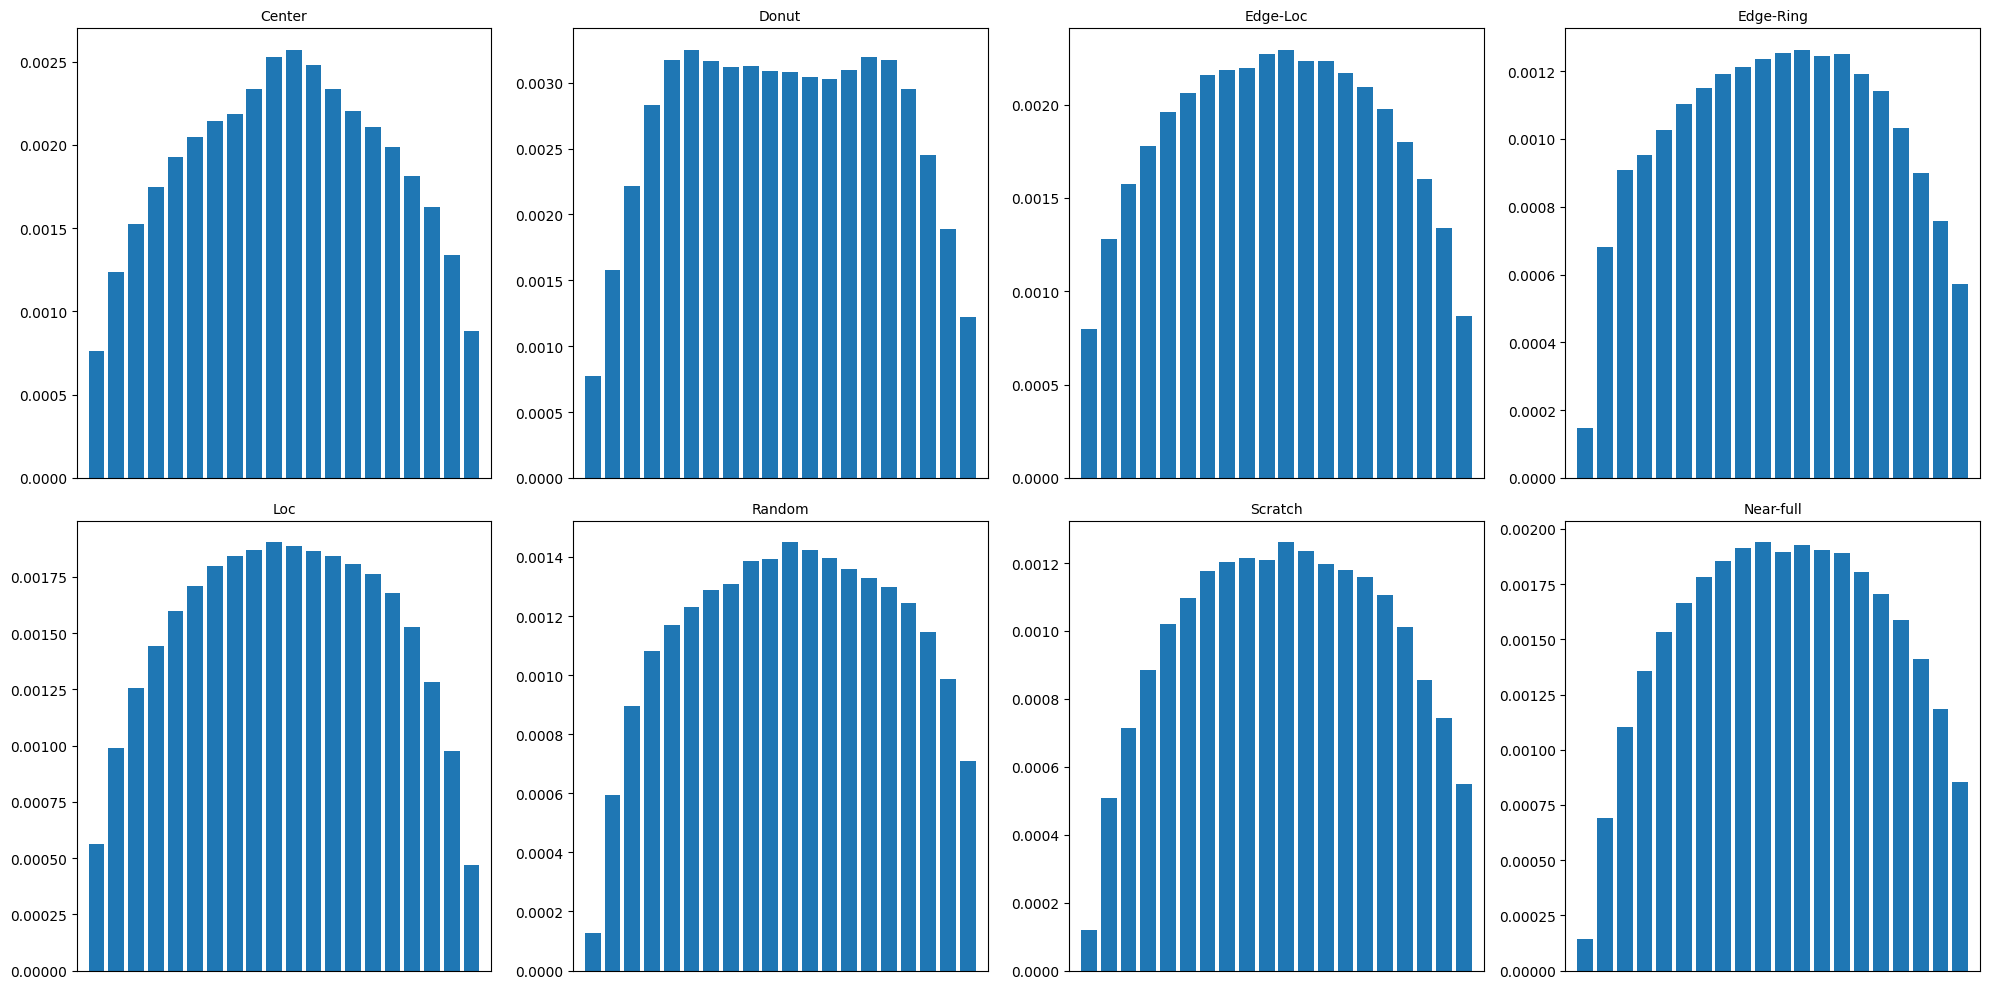

In [ ]:
# mean feature 시각화
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
ax = ax.ravel(order='C')
for i in range(8):
    ax[i].bar(np.linspace(1, 20, 20), df_withpattern_copy.fea_cub_mean[x[i]])
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0], fontsize=10)
    ax[i].set_xticks([])
    ax[i].set_xlim([0, 21])
plt.tight_layout()
plt.show()

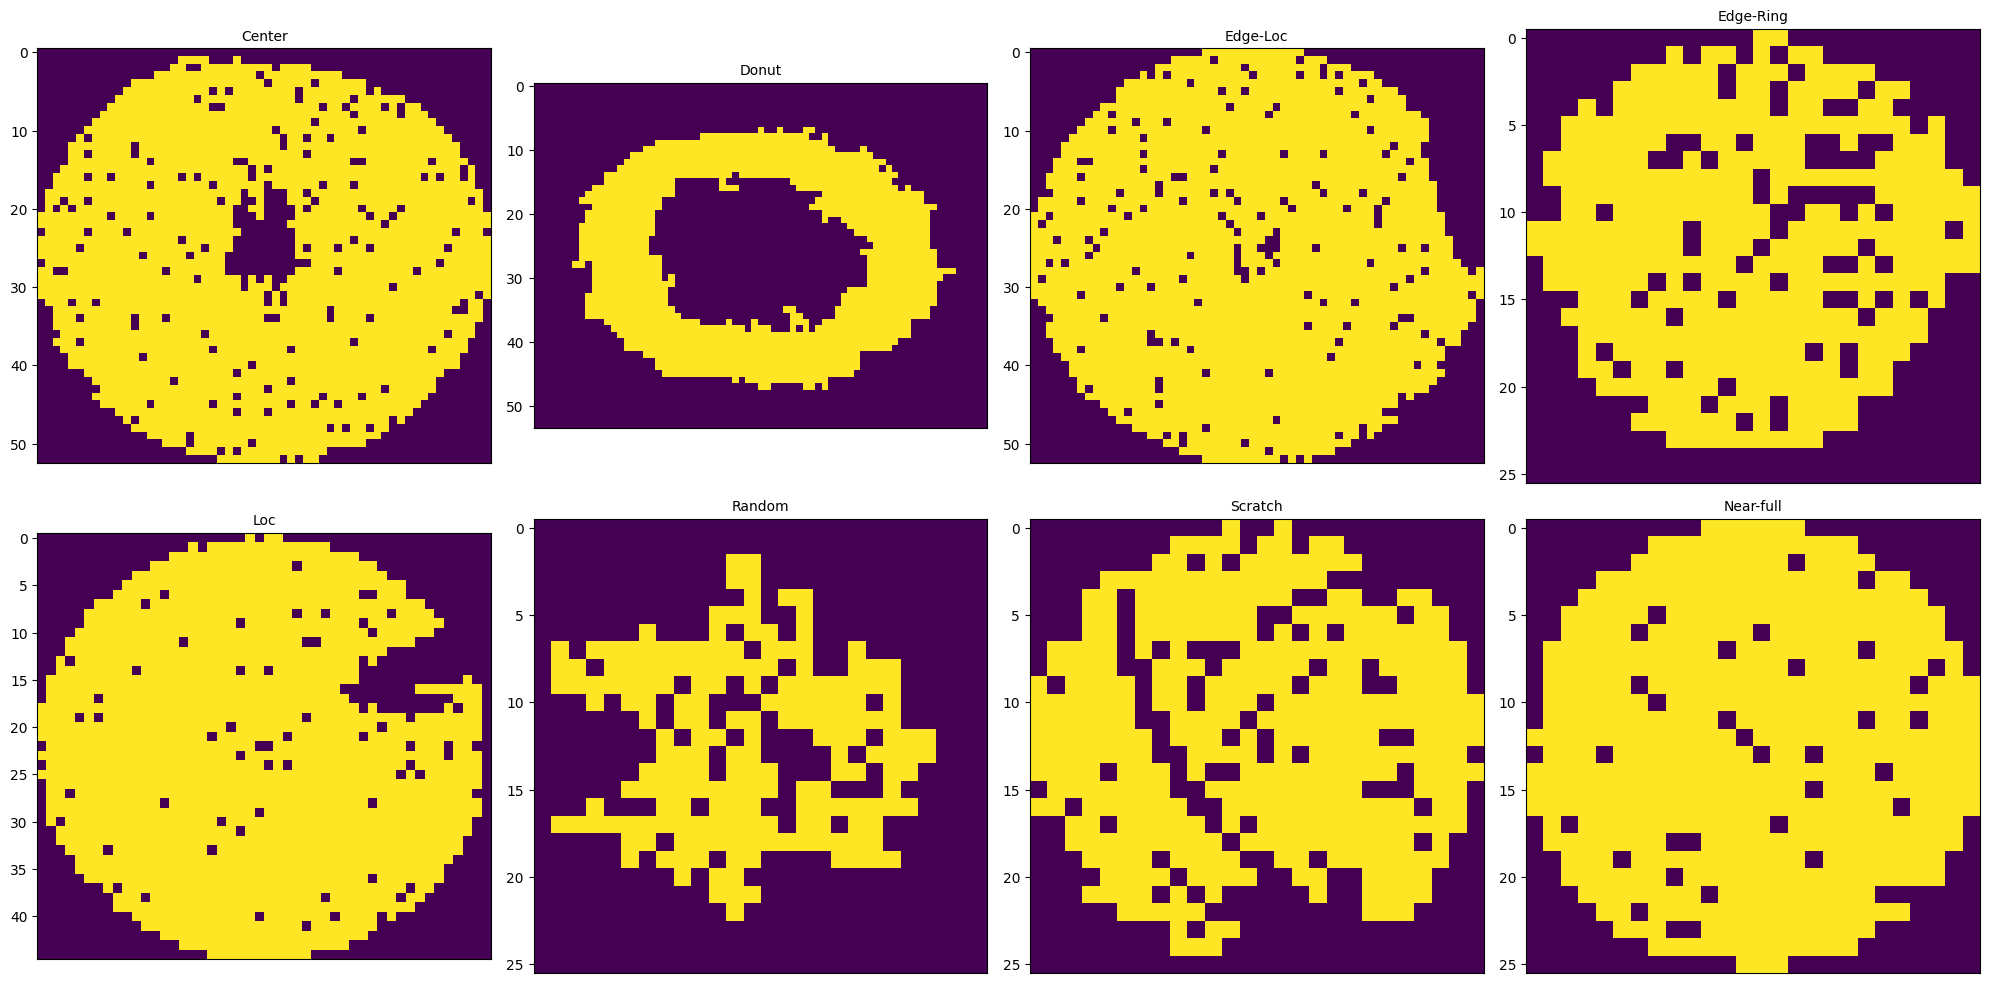

In [ ]:
# salient region 시각화
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
ax = ax.ravel(order='C')

for i in range(8):
    img = df_withpattern_copy.waferMap[x[i]]
    zero_img = np.zeros(img.shape)
    img_labels = measure.label(img, connectivity=1, background=0)
    img_labels = img_labels - 1

    if img_labels.max() == 0:
        no_region = 0
    else:
        info_region = stats.mode(img_labels[img_labels > -1], axis=None)
        no_region = info_region[0]

    zero_img[np.where(img_labels == no_region)] = 2
    ax[i].imshow(zero_img)
    ax[i].set_title(df_withpattern_copy.failureType[x[i]][0][0], fontsize=10)
    ax[i].set_xticks([])

plt.tight_layout()
plt.show()

In [ ]:
# 이미지 중심까지의 거리
def cal_dist(img, x, y):
    dim0 = np.size(img, axis=0)
    dim1 = np.size(img, axis=1)
    return np.sqrt((x - dim0/2)**2 + (y - dim1/2)**2)

# 기하 feature 6개 추출 (scipy 버전 분기 처리)
def fea_geom(img):
    norm_area      = img.shape[0] * img.shape[1]
    norm_perimeter = np.sqrt(img.shape[0]**2 + img.shape[1]**2)

    img_labels = measure.label(img, connectivity=1, background=0)

    if img_labels.max() == 0:
        img_labels[img_labels == 0] = 1
        no_region = 0
    else:
        info_region = stats.mode(img_labels[img_labels > 0], axis=None)
        try:
            no_region = int(info_region[0]) - 1        # scipy 최신
        except:
            no_region = int(info_region[0][0]) - 1     # scipy 구버전

    prop = measure.regionprops(img_labels)
    prop_area      = prop[no_region].area / norm_area
    prop_perimeter = prop[no_region].perimeter / norm_perimeter
    prop_cent      = prop[no_region].local_centroid
    prop_cent      = cal_dist(img, prop_cent[0], prop_cent[1])
    prop_majaxis   = prop[no_region].major_axis_length / norm_perimeter
    prop_minaxis   = prop[no_region].minor_axis_length / norm_perimeter
    prop_ecc       = prop[no_region].eccentricity
    prop_solidity  = prop[no_region].solidity

    return prop_area, prop_perimeter, prop_majaxis, prop_minaxis, prop_ecc, prop_solidity

df_withpattern_copy['fea_geom'] = \
    df_withpattern_copy.waferMap.progress_apply(fea_geom)
print("기하 feature 추출 완료")

100%|██████████| 25519/25519 [02:06<00:00, 202.50it/s]

기하 feature 추출 완료


In [ ]:
# 확인 (Donut 예시)
print(df_withpattern_copy.fea_geom[340])


(np.float64(0.30881585811163276), np.float64(3.4633305623147477), np.float64(0.7464951525564261), np.float64(0.5214489845402435), 0.7155811292862498, np.float64(0.6103092783505155))


In [ ]:
df_all = df_withpattern_copy.copy()

a = [df_all.fea_reg[i]          for i in range(df_all.shape[0])]  # 13
b = [df_all.fea_cub_mean[i]     for i in range(df_all.shape[0])]  # 20
c = [df_all.fea_cub_std[i]      for i in range(df_all.shape[0])]  # 20
d = [df_all.fea_geom[i]         for i in range(df_all.shape[0])]  #  6
kk = [df_all.fea_selective[i]      for i in range(df_all.shape[0])]  # 40

fea_all = np.concatenate(
    (np.array(a),  np.array(b),  np.array(c),  np.array(d),
     np.array(kk)),
    axis=1
)
print(f"feature 형태: {fea_all.shape}")  # → (25519, 219)
label = np.array([df_all.failureNum[i] for i in range(df_all.shape[0])])

print("최종 feature 형태:", fea_all.shape)   # → (25519, 59)
print("라벨 형태:", label.shape)              # → (25519,)


feature 형태: (25519, 99)
최종 feature 형태: (25519, 99)
라벨 형태: (25519,)


In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = fea_all
y = label

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)
print(f"PCA 후 차원: {X_train.shape[1]}")

print("Train 분포:", Counter(y_train))
print("Test  분포:", Counter(y_test))

PCA 후 차원: 24
Train 분포: Counter({np.int64(3): 7299, np.int64(2): 3860, np.int64(0): 3238, np.int64(4): 2677, np.int64(6): 905, np.int64(5): 640, np.int64(1): 404, np.int64(7): 116})
Test  분포: Counter({np.int64(3): 2381, np.int64(2): 1329, np.int64(0): 1056, np.int64(4): 916, np.int64(6): 288, np.int64(5): 226, np.int64(1): 151, np.int64(7): 33})


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsOneClassifier

RANDOM_STATE = 42
clf = OneVsOneClassifier(LinearSVC(random_state=RANDOM_STATE))
clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred  = clf.predict(X_test)

train_acc = np.sum(y_train == y_train_pred) / len(y_train) * 100
test_acc  = np.sum(y_test  == y_test_pred)  / len(y_test)  * 100

print(f"Train Accuracy: {train_acc:.2f}%")   # → 77.34%
print(f"Test  Accuracy: {test_acc:.2f}%")    # → 76.83%


Train Accuracy: 83.43%
Test  Accuracy: 82.60%


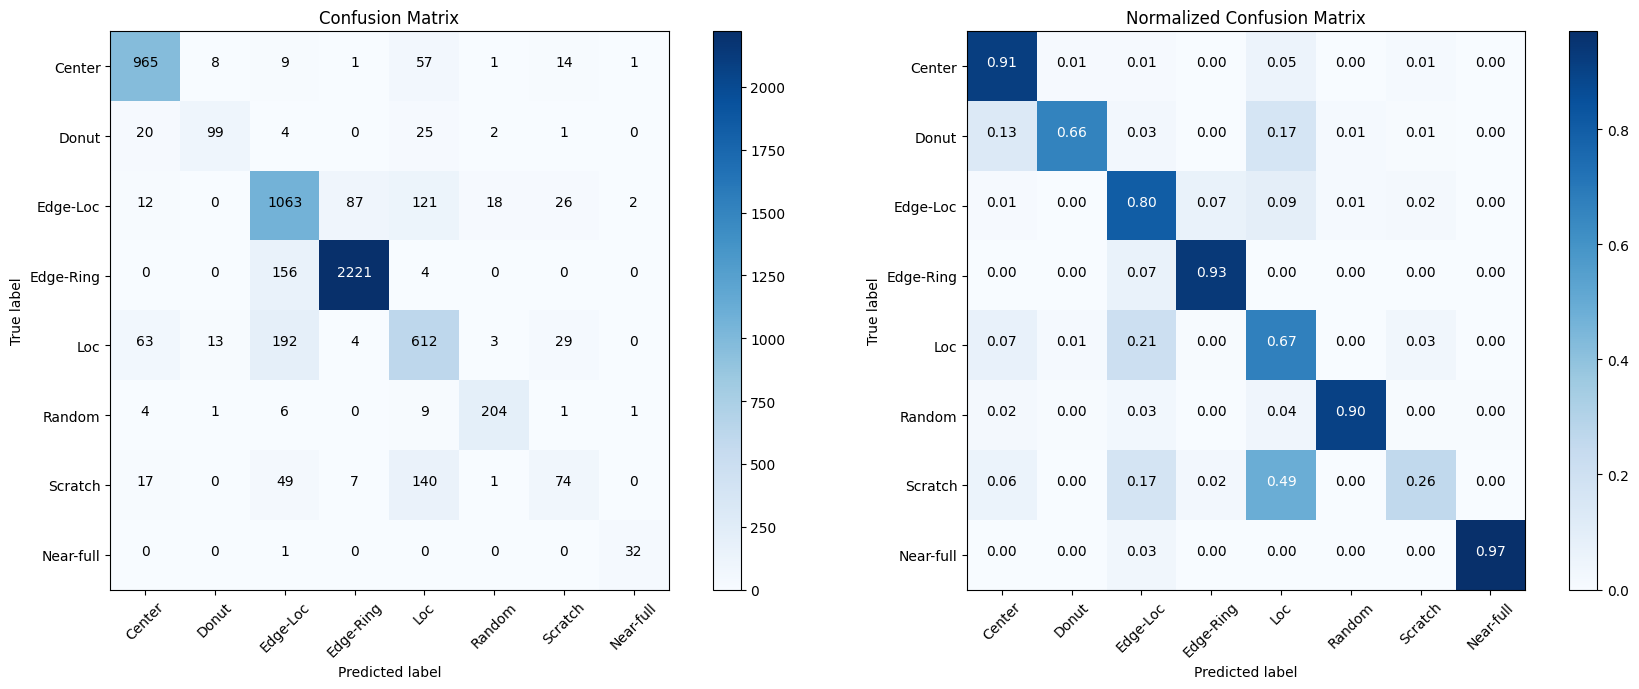

In [ ]:
import itertools
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(cm, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    classes = ['Center','Donut','Edge-Loc','Edge-Ring',
               'Loc','Random','Scratch','Near-full']
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), horizontalalignment="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
cnf_matrix = confusion_matrix(y_test, y_test_pred)

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(1, 2)

plt.subplot(gs[0])
plot_confusion_matrix(cnf_matrix, title='Confusion Matrix')

plt.subplot(gs[1])
plot_confusion_matrix(cnf_matrix, normalize=True,
                      title='Normalized Confusion Matrix')
plt.show()


In [ ]:
# 클래스별 Precision / Recall / F1 출력
print(classification_report(
    y_test, y_test_pred,
    target_names=['Center','Donut','Edge-Loc','Edge-Ring',
                  'Loc','Random','Scratch','Near-full']
))


              precision    recall  f1-score   support

      Center       0.89      0.91      0.90      1056
       Donut       0.82      0.66      0.73       151
    Edge-Loc       0.72      0.80      0.76      1329
   Edge-Ring       0.96      0.93      0.94      2381
         Loc       0.63      0.67      0.65       916
      Random       0.89      0.90      0.90       226
     Scratch       0.51      0.26      0.34       288
   Near-full       0.89      0.97      0.93        33

    accuracy                           0.83      6380
   macro avg       0.79      0.76      0.77      6380
weighted avg       0.82      0.83      0.82      6380

